In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Cell 2 — Version 1: the key difference — random feature subsets
# Normal tree: considers ALL features at each split
# Random Forest: considers sqrt(n_features) at each split → more diversity

def gini(y):
    if len(y) == 0: return 0
    counts = np.bincount(y.astype(int), minlength=2)
    probs  = counts / len(y)
    return 1 - np.sum(probs**2)

def best_split_random(X, y, n_features_subset):
    """Pick random subset of features, then find best split among them."""
    n_features  = X.shape[1]
    feat_subset = np.random.choice(n_features, size=n_features_subset, replace=False)

    best_ig, best_feat, best_thresh = -1, None, None
    parent_gini = gini(y)

    for feat in feat_subset:
        thresholds = np.unique(X[:, feat])
        for thresh in thresholds:
            left  = y[X[:, feat] < thresh]
            right = y[X[:, feat] >= thresh]
            if len(left)==0 or len(right)==0: continue
            weighted = (len(left)*gini(left) + len(right)*gini(right)) / len(y)
            ig = parent_gini - weighted
            if ig > best_ig:
                best_ig, best_feat, best_thresh = ig, feat, thresh

    return best_feat, best_thresh

print("Random feature subset split function defined ✅")
print("sqrt(4 features) = 2 features checked per split")

Random feature subset split function defined ✅
sqrt(4 features) = 2 features checked per split


In [3]:
# Cell 3 — Version 2: RandomForest class from scratch
class RFNode:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=5, n_features_subset=None):
        self.n_trees           = n_trees
        self.max_depth         = max_depth
        self.n_features_subset = n_features_subset
        self.trees             = []

    def _build(self, X, y, depth=0):
        n_feat = self.n_features_subset or max(1, int(np.sqrt(X.shape[1])))
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < 2:
            return RFNode(value=Counter(y.astype(int)).most_common(1)[0][0])
        feat, thresh = best_split_random(X, y, n_feat)
        if feat is None:
            return RFNode(value=Counter(y.astype(int)).most_common(1)[0][0])
        mask  = X[:, feat] < thresh
        left  = self._build(X[mask],  y[mask],  depth+1)
        right = self._build(X[~mask], y[~mask], depth+1)
        return RFNode(feature=feat, threshold=thresh, left=left, right=right)

    def _predict_one(self, x, node):
        if node.value is not None: return node.value
        if x[node.feature] < node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_trees):
            idx    = np.random.choice(len(X), size=len(X), replace=True)
            X_boot, y_boot = X[idx], y[idx]
            tree   = self._build(X_boot, y_boot)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([[self._predict_one(x, t) for x in X]
                               for t in self.trees])
        return np.apply_along_axis(
            lambda col: Counter(col.astype(int)).most_common(1)[0][0],
            axis=0, arr=all_preds)

print("RandomForestScratch class defined ✅")

RandomForestScratch class defined ✅


In [4]:
# Cell 4 — Version 3: train and compare single tree vs RF
np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=4, n_redundant=0,
                            n_informative=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier

single = DecisionTreeClassifier(max_depth=None, random_state=42)
single.fit(X_train, y_train)
single_acc = accuracy_score(y_test, single.predict(X_test))

rf = RandomForestScratch(n_trees=30, max_depth=6)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Single Decision Tree accuracy: {single_acc*100:.1f}%")
print(f"Random Forest (30 trees) acc:  {rf_acc*100:.1f}%")
print("Random Forest should be higher — less overfitting ✅")

Single Decision Tree accuracy: 84.0%
Random Forest (30 trees) acc:  86.0%
Random Forest should be higher — less overfitting ✅


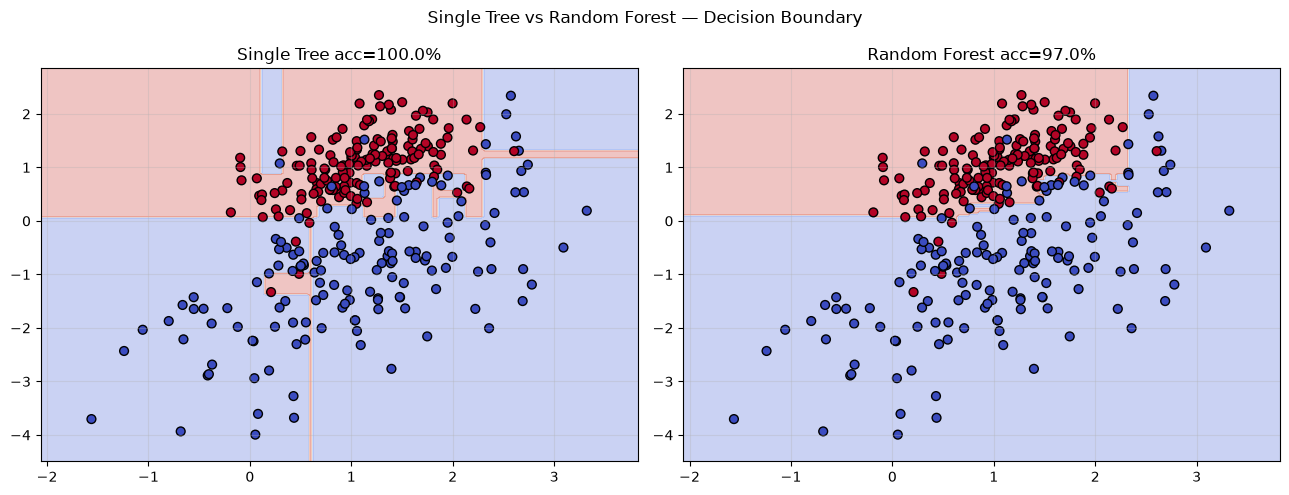

Single tree = jagged boundary (overfit). RF = smoother ✅


In [5]:
# Cell 5 — Version 4: decision boundary — single tree vs RF
np.random.seed(0)
X2, y2 = make_classification(n_samples=300, n_features=2, n_redundant=0,
                              n_informative=2, random_state=0, n_clusters_per_class=1)

single2 = DecisionTreeClassifier(max_depth=None, random_state=0)
single2.fit(X2, y2)

rf2 = RandomForestScratch(n_trees=25, max_depth=6)
rf2.fit(X2, y2)

x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid   = np.c_[xx.ravel(), yy.ravel()]

Z1 = single2.predict(grid).reshape(xx.shape)
Z2 = rf2.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, title in zip(axes,
                         [Z1, Z2],
                         [f'Single Tree acc={accuracy_score(y2, single2.predict(X2))*100:.1f}%',
                          f'Random Forest acc={accuracy_score(y2, rf2.predict(X2))*100:.1f}%']):
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X2[:,0], X2[:,1], c=y2, cmap='coolwarm', edgecolors='k', s=40)
    ax.set_title(title); ax.grid(True, alpha=0.3)

plt.suptitle('Single Tree vs Random Forest — Decision Boundary')
plt.tight_layout(); plt.show()
print("Single tree = jagged boundary (overfit). RF = smoother ✅")